In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
import string

In [2]:
df = pd.read_csv('../data/phishing_email.csv')
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [4]:
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [5]:
(df['text_combined'].astype(str).str.strip() == '').sum()

1

In [6]:
df = df[df['text_combined'].astype(str).str.strip() != '']

In [7]:
df.duplicated().sum()

408

In [8]:
df = df.drop_duplicates()

In [9]:
df['label'].value_counts()

label
1    42844
0    39233
Name: count, dtype: int64

In [13]:
df['label'] = df['label'].astype(str).str.strip().str.lower()

In [14]:
df['label'] = df['label'].replace({
    'legitimate': 'safe',
    'ham': 'safe',
    'phishing email': 'phishing'
})

In [15]:
df['clean_text'] = df['text_combined'].astype(str).str.lower()

In [16]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))


In [19]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\S+@\S+', '', x))

In [20]:
df['clean_text'] = df['clean_text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

In [21]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\d+', '', x))

In [22]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [23]:
df[['text_combined', 'clean_text']].head(5)

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...


In [25]:
df['text_length'] = df['clean_text'].apply(len)
print(df['text_length'])

0          49
1         880
2         109
3          49
4          50
         ... 
82481    1394
82482     168
82483     815
82484     348
82485     743
Name: text_length, Length: 82077, dtype: int64


In [26]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print(df['word_count'])

0         10
1        152
2         17
3         10
4         10
        ... 
82481    199
82482     18
82483    101
82484     44
82485    108
Name: word_count, Length: 82077, dtype: int64


In [27]:
df['digit_count'] = df['clean_text'].apply(lambda x: sum(c.isdigit() for c in x))
print(df['digit_count'])

0        0
1        0
2        0
3        0
4        0
        ..
82481    0
82482    0
82483    0
82484    0
82485    0
Name: digit_count, Length: 82077, dtype: int64


In [28]:
df['uppercase_count'] = df['text_combined'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()))
print(df['uppercase_count'])

0        0
1        0
2        0
3        0
4        0
        ..
82481    0
82482    0
82483    0
82484    0
82485    0
Name: uppercase_count, Length: 82077, dtype: int64


In [29]:
df['special_char_count'] = df['text_combined'].astype(str).apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()))
print(df['special_char_count'])

0         0
1         0
2         0
3         0
4         0
         ..
82481    34
82482     0
82483     2
82484     0
82485     2
Name: special_char_count, Length: 82077, dtype: int64


In [31]:
df['has_url'] = df['text_combined'].astype(str).apply(lambda x: 1 if re.search(r'http\S+|www\S+|https\S+', x) else 0)
print(df["has_url"].value_counts())

has_url
0    49089
1    32988
Name: count, dtype: int64


In [32]:
df['has_email'] = df['text_combined'].astype(str).apply(lambda x: 1 if re.search(r'\S+@\S+', x) else 0)
print(df['has_email'].value_counts())

has_email
0    82077
Name: count, dtype: int64


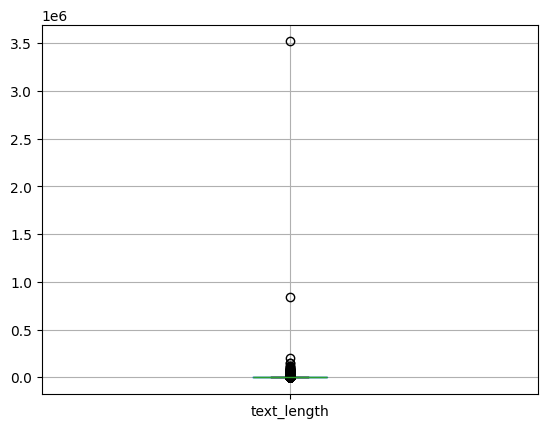

In [33]:
df.boxplot(column='text_length')
plt.show()

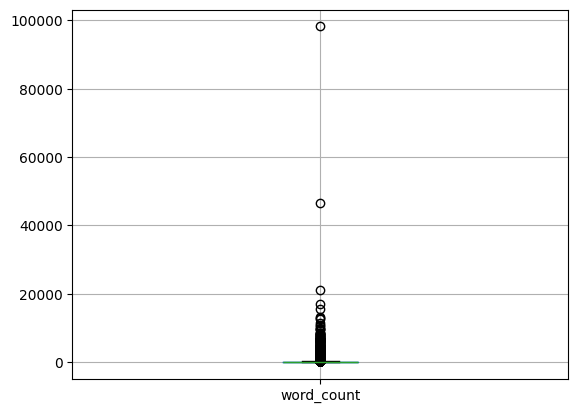

In [34]:
df.boxplot(column='word_count')
plt.show()

In [35]:
Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [36]:
outliers = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]
outliers.shape

(6372, 10)

In [ ]:
df['text_length'] = np.where(df['text_length'] > upper_bound, upper_bound, df['text_length'])

0          49.0
1         880.0
2         109.0
3          49.0
4          50.0
          ...  
82481    1394.0
82482     168.0
82483     815.0
82484     348.0
82485     743.0
Name: text_length, Length: 82077, dtype: float64


# MinMax

In [39]:
scaler = MinMaxScaler()
numeric_cols = ['text_length', 'word_count', 'digit_count', 'uppercase_count', 'special_char_count']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Standard Scaler

In [40]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Label Encoding

In [43]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print(df['label_encoded'].value_counts())

label_encoded
1    42844
0    39233
Name: count, dtype: int64


In [42]:
list(le.classes_)

['0', '1']

In [45]:
df.head()


,text_combined,label,clean_text,text_length,word_count,digit_count,uppercase_count,special_char_count,has_url,has_email,label_encoded
0,hpl nom may 25 2001 see attached file hplno 52...,0,hpl nom may see attached file hplno xls hplno xls,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0,nom actual vols th forwarded sabrae zajac hou ...,0.127212,0.019503,-0.014909,-0.00399,-0.177516,0,0,0
2,enron actuals march 30 april 1 201 estimated a...,0,enron actuals march april estimated actuals ma...,-0.933162,-0.251457,-0.014909,-0.00399,-0.177516,0,0,0
3,hpl nom may 30 2001 see attached file hplno 53...,0,hpl nom may see attached file hplno xls hplno xls,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0,0
4,hpl nom june 1 2001 see attached file hplno 60...,0,hpl nom june see attached file hplno xls hplno...,-1.014306,-0.265507,-0.014909,-0.00399,-0.177516,0,0,0


In [46]:
df.shape

(82077, 11)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82077 entries, 0 to 82485
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   text_combined       82077 non-null  object 
 1   label               82077 non-null  object 
 2   clean_text          82077 non-null  object 
 3   text_length         82077 non-null  float64
 4   word_count          82077 non-null  float64
 5   digit_count         82077 non-null  float64
 6   uppercase_count     82077 non-null  float64
 7   special_char_count  82077 non-null  float64
 8   has_url             82077 non-null  int64  
 9   has_email           82077 non-null  int64  
 10  label_encoded       82077 non-null  int32  
dtypes: float64(5), int32(1), int64(2), object(3)
memory usage: 7.2+ MB


In [48]:
processed_df = df[['clean_text', 'label', 'label_encoded', 'text_length', 'word_count',
                   'digit_count', 'uppercase_count', 'special_char_count', 'has_url', 'has_email']]
processed_df.head()

,clean_text,label,label_encoded,text_length,word_count,digit_count,uppercase_count,special_char_count,has_url,has_email
0,hpl nom may see attached file hplno xls hplno xls,0,0,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0
1,nom actual vols th forwarded sabrae zajac hou ...,0,0,0.127212,0.019503,-0.014909,-0.00399,-0.177516,0,0
2,enron actuals march april estimated actuals ma...,0,0,-0.933162,-0.251457,-0.014909,-0.00399,-0.177516,0,0
3,hpl nom may see attached file hplno xls hplno xls,0,0,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0
4,hpl nom june see attached file hplno xls hplno...,0,0,-1.014306,-0.265507,-0.014909,-0.00399,-0.177516,0,0


In [49]:
processed_df.to_csv('../data/phishing_email_preprocessed.csv', index=False)